###Μηχανική Μάθηση
####1η ατομική εργασία
ΣΗΜΜΥ- ΕΜΠ -Ακ. Έτος 2025-26



# ⚠️
`Επισημαίνεται ότι απαγορεύεται η ανάρτηση των λύσεων των εργαστηριακών ασκήσεων στο github, ή σε άλλες ιστοσελίδες. Η σχεδίαση και το περιεχόμενο των εργαστηριακών projects αποτελούν αντικείμενο πνευματικής ιδιοκτησίας της διδακτικής ομάδας του μαθήματος.`

 `⚠️  Το σύνολο δεδομένων που σας δόθηκε δεν πρέπει να εμπλουτισθεί με οποιοδήποτε τρόπο. Η εργασία στην οποία θα χρησιμοποιηθεί εμπλουτισμένο σύνολο δεδομένων, δεν θα διορθωθεί.`

Ονοματεπώνυμο φοιτητή: Tσουρούφλη Ζωή

Α.Μ.: 03122062

### 1. Εισαγωγή συνόλου δεδομένων

Tο σύνολο δεδομένων για το training-validation μπορείτε να το κατεβάσετε από [εδώ](https://drive.google.com/file/d/1PRxhsDEF6em2Ut095c790CbBmuDdSgr5/view?usp=sharing).


**1.α. Φορτώστε το σύνολο δεδομένων "train-val.csv"  στο notebook σας.**

In [222]:
import pandas as pd

df = pd.read_csv("train-val.csv")

print(df.head()) # εμφάνισε τις πρώτες γραμμές για έλεγχο


         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2009-03-22   Albury     14.6     30.0       0.0          NaN       NaN   
1  2009-04-15   Albury     10.7     21.9       0.0          NaN       NaN   
2  2009-04-21   Albury      5.7     21.4       0.0          NaN       NaN   
3  2009-04-24   Albury     10.6     16.2       0.0          NaN       NaN   
4  2009-05-19   Albury      3.7     19.1       0.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0          NE           37.0          E  ...        56.0         30.0   
1           W           63.0         NW  ...        44.0         27.0   
2         ESE           17.0        ENE  ...        68.0         39.0   
3         WNW           39.0        ESE  ...        74.0         86.0   
4         SSE           19.0        NaN  ...        87.0         51.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1014.8    

In [223]:
#κάνε εδώ import κάποια πράγματα που θα χρειαστούν στη συνέχεια
import numpy as np
from sklearn.preprocessing import MinMaxScaler

### 2. Διερευνητική ανάλυση δεδομένων -Exploratory Data Analysis (EDA)
Χρησιμοποιήστε code cells  με τις κατάλληλες τεχνικές EDA για την κατανόηση του συνόλου δεδομένων και text cells για επεξήγηση των αποτελεσμάτων.

Χρησιμοποιώντας τις κατάλληλες μεθόδους παρουσιάστε με χρήση κώδικα πληροφορίες για τα εξής:

2α. το πλήθος των δειγμάτων και των χαρακτηριστικών του συνόλου δεδομένων,

2β. το είδος των χαρακτηριστικών του συνόλου δεδομένων,  

2γ. τις ετικέτες των χαρακτηριστικών,

2δ. το πλήθος των κατηγοριών,

2ε. πόσα δείγματα ανήκουν σε κάθε κατηγορία,

2στ. τη συσχέτιση μεταξύ των δεδομένων,

2ζ. οποιαδήποτε άλλη πληροφορία πιστεύετε ότι είναι χρήσιμη για την κατανόηση του συνόλου δεδομένων.

**2α. πλήθος των δειγμάτων και των χαρακτηριστικών του συνόλου δεδομένων**


In [224]:
#υπολογίζω το πλήθος των δειγμάτων βρίσκοντας πόσες γραμμές έχει το αρχείο
plithosdeigmaton=(len(df))
print("Το πλήθος των δειγμάτων είναι : ", plithosdeigmaton)

#υπολογίζω το πλήθος χαρακτηριστικών του συνόλου δεδομένων βρίσκοντας πόσες είναι οι στήλες
xaraktiristikadedomenon=len(df.columns)
print("To πλήθος των χαρακτηριστικών του συνόλου δεδομένων είναι : ", xaraktiristikadedomenon)

Το πλήθος των δειγμάτων είναι :  10000
To πλήθος των χαρακτηριστικών του συνόλου δεδομένων είναι :  23


**2β. το είδος των χαρακτηριστικών του συνόλου δεδομένων**


In [225]:
#εμφανίζω τον τύπο των δεδομένων που δίνονται. Τα χαρακτηριστικά που εμφανίζουν τον τύπο object είναι συνήθως string (κατηγορικά χαρακτηριστικά),
#ενώ τα χαρακτηριστικά με τύπο float64 είναι αριθμοί κινητής υποδιαστολής (αριθμητικά χαρακτηριστικά)
print(df.dtypes)

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object


**2γ. τις ετικέτες των χαρακτηριστικών**

In [226]:
etiketesxaraktiristikon = df.drop('RainTomorrow', axis=1)
print("Οι ετικέτες των χαρακτηριστικών είναι οι εξής:")
etiketesxaraktiristikon.columns
#έχω εξαιρέσει την RainTomorrow γιατί είναι το target label όχι feature

Οι ετικέτες των χαρακτηριστικών είναι οι εξής:


Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday'],
      dtype='object')

**2δ.το πλήθος των κατηγοριών**

Ψάχνω να βρω το πλήθος των διαφορετικών απαντήσεων του Rain Tomorrow  

In [227]:
df['RainTomorrow'].unique()

array(['No', 'Yes', nan], dtype=object)

Άρα το πλήθος των κατηγοριώνν είναι 3!

**2ε. πόσα δείγματα ανήκουν σε κάθε κατηγορία**

In [228]:
df['RainTomorrow'].value_counts(dropna=False)

,count
RainTomorrow,
No,7483
Yes,2317
NaN,200


**2στ. τη συσχέτιση μεταξύ των δεδομένων**

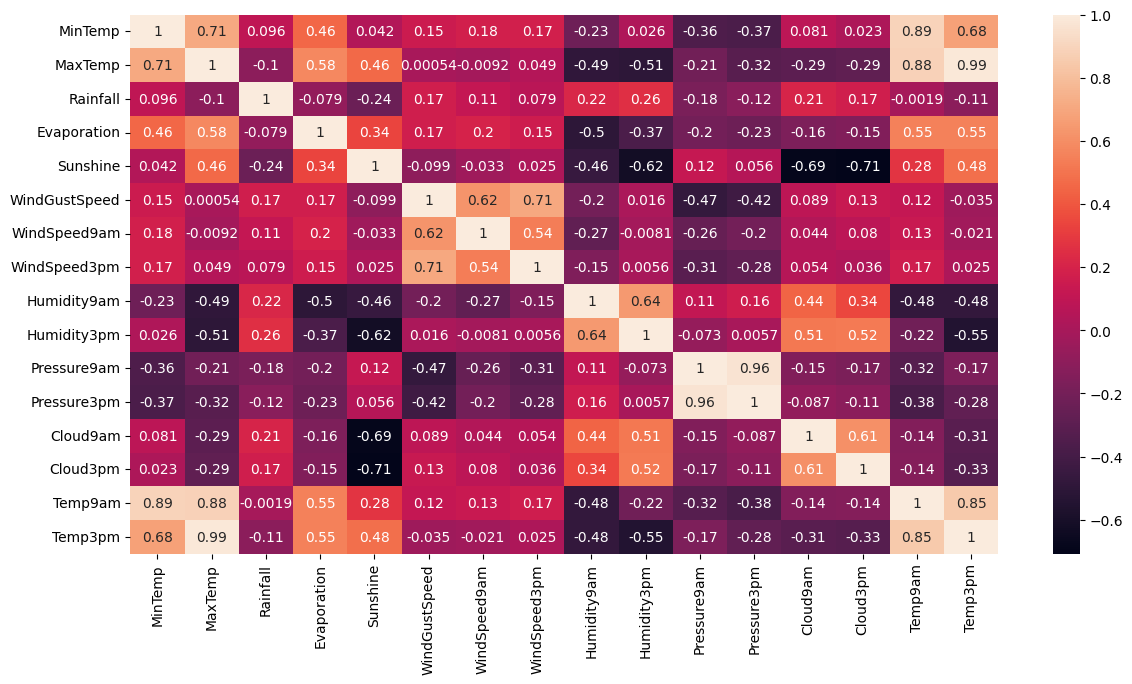

In [229]:
import seaborn as sns
import matplotlib.pyplot as plt

#είναι δυνατόν σε αυτό το σημείο να βρω τη συσχέτιση των αριθμητικών χαρακτηριστικών, καθώς δεν έχω φέρει ακόμα σε κατάλληλη μορφή τα κατηγορικά
corr = df.corr(numeric_only=True)  #εδώ υπολογίζουμε το correlation θα μπορούσαμε
                                   #να το αφήσουμε εδώ αλλά το οπτικοποιούμε
plt.figure(figsize=(14,7))
sns.heatmap(corr, annot=True)
plt.show()

Παρατηρώ ότι αρκετά χαρακτηριστικά συσχετίζονται άμεσα μεταξύ τους. Αυτή η πληροφροία στη συνέχεια θα φανεί χρήσιμη για την επιλογή των χαρακτηριστικών που θα κρατηθούν για την εκπαίδευση και πρόβλεψη. Πιθανότατα κατηγορίες που σχετίζονται πολύ μεταξύ τους και λίγο με το rain_tomorrow δεν θα μου φανούν ιδιαίτερα χρήσιμες.

**2ζ. οποιαδήποτε άλλη πληροφορία πιστεύετε ότι είναι χρήσιμη για την κατανόηση του συνόλου δεδομένων**

Επιλέγω να δω ποια χαρακτηριστικά έχουν τις περισσότερες κενές τιμές. Ταξινομώ από τα χαρακτηριστικά με το μεγαλύτερος πλήθος nan (κενών) τιμών στα χαρακτηριστικά με το μικρότερο πλήθος.
Αυτό μπορεί να είναι χρήσιμο στη συνέχεια γιατί μπορεί να χρησιμοποιήσω την πληροφορία αυτή για να αποφασίσω ποια είναι πιο χρήσιμα δείγματα από άλλα.

In [230]:
df.isna().sum().sort_values(ascending=False)


,0
Sunshine,4825
Evaporation,4337
Cloud3pm,4050
Cloud9am,3845
Pressure3pm,1030
Pressure9am,1027
WindDir9am,795
WindGustDir,748
WindGustSpeed,744
WindDir3pm,312


### 3. Προεπεξεργασία συνόλου δεδομένων
💡`Χρησιμοποιήστε το Column Transformer για τη δημιουργία και την εφαρμογή χωριστών μετασχηματιστών για αριθμητικά και κατηγορικά δεδομένα.`




**3.α.  Θα χρησιμοποιήσετε όλα τα χαρακτηριστικά του συνόλου δεδομένων για την εκπαίδευση των ταξινομητών ή θα επιλέξετε κάποια από αυτά;  Θα κάνετε κάποια συνένωση κάποιων χαρακτηριστικών για δημιουργία νέων χαρακτηριστικών για το μοντέλο σας;**


Στο κομμάτι αυτό επεξεργάζομαι τα δεδομένα μου, κρατάω τα πιο χρήσιμα και σχετικά. Κάνω χρήση συναρτήσεων για την επεξεργασία αυτή, για να μπορώ να κάνω με ευκολία ανάλογη επεξεργασία στη συνέχεια.

In [231]:
def create_features(df_input):

  df_out = df_input.copy()

  #διαφορά θερμοκρασίας
  df_out['TempDiff'] = df_out['MaxTemp'] - df_input['MinTemp']
  #διαφορά υγρασίας
  df_out['HumidityDiff'] = df_out['Humidity9am'] - df_out['Humidity3pm']
  #μέση ένταση ανέμου
  df_out['WindSpeedMean'] = (df_out['WindSpeed9am'] + df_out['WindSpeed3pm']) / 2
  #μέση νεφοκάλυψη
  df_out['CloudMean'] = (df_out['Cloud9am'] + df_out['Cloud3pm']) / 2
  #μέση υγρασία
  df_out['HumidityMean'] = (df_out['Humidity9am'] + df_out['Humidity3pm']) / 2
  #μέση θερμοκρασία
  df_out['TempMean'] = (df_out['MaxTemp'] + df_out['MinTemp']) / 2
  #μέση πίεση
  df_out['PressureMean'] = (df_out['Pressure9am'] + df_out['Pressure3pm']) / 2

  #δεν χρειάζεται να χρησιμοποιήσω και το pressure9am και το pressure3pm γιατί έχουν πολύ υψηλή συσχέτιση της τάξης του 0.96
  df_out = df_out.drop(columns=['Pressure9am'])
  #δεν χρειάζεται να χρησιμοποιήσω και το max temp και το temp3pm γιατί έχουν πολύ υψηλή συσχέτιση της τάξης του 0.99
  df_out = df_out.drop(columns=['Temp3pm'])

  return df_out

In [232]:
#εφαρμόζω τη συνάρτηση
df=create_features(df)

In [233]:
def create_features2(df_input):

  df_out = df_input.copy()

  #τώρα φτιάχνω μερικές απλές συναρτήσεις με βάση τα features που έχω στην κατοχή μου

  #thermal instability : #μεγάλη διαφορά θερμοκρασίας και μικρή πίεση ευνοεί καταιγίδες
  df_out['ThermalInstability'] = (df_out['MaxTemp'] - df_out['MinTemp']) / df_out['Pressure3pm']
  #rain momentum : αν έβρεξε σήμερα και έχει υψηλή υγρασία είναι πιθανό να βρέξει και αύριο
  df_out['RainMomentum'] = (df_out['RainToday'].map({'Yes':1, 'No':0}) * (df_out['Humidity3pm'] / 100))

  return df_out

In [234]:
#εφαρμόζω τη συνάρτηση
df=create_features2(df)

In [235]:
def make_rain_binary(df_input):

  df_out = df_input.copy()

  #μετατρέπω το Rain Tomorrow σε binary για να το συγκρίνω με τα υπόλοιπα αριθμητικά δεδομένα/χαρακτηριστικά που διαθέτω
  df_out['RainTomorrow_num'] = df_out['RainTomorrow'].map({'Yes': 1, 'No': 0})
  #μετατρέπω το Rain Today σε binary για να το συγκρίνω με τα υπόλοιπα αριθμητικά δεδομένα/χαρακτηριστικά που διαθέτω
  df_out['RainToday_num'] = df_out['RainToday'].map({'Yes': 1, 'No': 0})

  return df_out

In [236]:
#εφαρμόζω τη συνάρτηση
df=make_rain_binary(df)

In [237]:
#υπολογίζω τη συσχέτιση μεταξύ του RainTomorrow και των αριθμητικών χαρακτηριστικών που έχω για να αποφασίσω πως θα αξιοποιήσω τα υπόλοιπα δεδομένα μου
corr = df.corr(numeric_only=True)['RainTomorrow_num'].sort_values(ascending=False)
print(corr)

RainTomorrow_num      1.000000
Humidity3pm           0.443945
CloudMean             0.396520
HumidityMean          0.374410
Cloud3pm              0.371287
RainMomentum          0.363754
Cloud9am              0.320732
RainToday_num         0.304466
WindGustSpeed         0.275468
Rainfall              0.246445
Humidity9am           0.228328
WindSpeedMean         0.152489
WindSpeed9am          0.144810
WindSpeed3pm          0.120427
MinTemp               0.083477
Temp9am              -0.034774
TempMean             -0.058390
Evaporation          -0.100744
MaxTemp              -0.180514
Pressure3pm          -0.265795
PressureMean         -0.282152
HumidityDiff         -0.283053
ThermalInstability   -0.349089
TempDiff             -0.350648
Sunshine             -0.443789
Name: RainTomorrow_num, dtype: float64


  Ελέγχω λίγο τα χαρακτηριστικά και τα δείγματα που έχω στη διάθεση μου. Παίρνω 5 τυχαία

In [238]:
print(df.sample(5))

            Date       Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
1869  2015-09-18        Penrith     12.8     20.8       0.2          NaN   
2125  2008-05-05         Sydney      9.4     22.3       0.0          2.0   
1559  2010-09-08  NorfolkIsland     15.6     17.7      23.8          4.0   
7448  2017-04-13        Woomera     11.3     27.9       0.0          6.4   
1543  2010-03-26  NorfolkIsland     19.3     25.0       0.4          6.8   

      Sunshine WindGustDir  WindGustSpeed WindDir9am  ... HumidityDiff  \
1869       NaN         SSE           26.0        SSW  ...         12.0   
2125      10.0         NaN            NaN          W  ...         37.0   
1559       0.0         SSE           24.0        SSE  ...         10.0   
7448       NaN           S           31.0          E  ...         19.0   
1543       8.1          SE           37.0         SE  ...         11.0   

      WindSpeedMean  CloudMean  HumidityMean  TempMean  PressureMean  \
1869           15.0       

Παρατηρώ ότι τα εξής : Humidity3pm , Cloud3pm, Sunshine  και TempDiff συνδέονται πολύ με τη πιθανότητα βροχής (επέλεξα τα 4 με τη μεγαλύτερη κατά απόλυτη τιμή συσχέτιση)

In [239]:
#θα φτιάξω μία συνάρτηση την οποία θα ονομάσω RainIndex και η οποία θα λαμβάνει υπόψιν της με διαφορετικούς
#συντελεστές βαρύτητας τα 4 χαρακτηριστικά που έχουν μεγάλη συσχέτιση με το RainTomorrow που αναφέραμε από πάνω

#df['RainIndex'] = (0.5 * (df['Humidity3pm'] / 100) + 0.2 * (df['Cloud3pm'] / 8) + 0.1 * (1 - df['TempDiff'] / df['TempDiff'].max()) +
    # 0.4 * (1 - df['Sunshine'] / df['Sunshine'].max()))
#τελικά δεν την χρησιμοποίησα άλλα την παραθέτω σαν μέρος του πειραματισμού μου

In [240]:
#έλεγχος της σχετικότητας του index με το target label
#df[['RainIndex', 'RainTomorrow_num']].corr()

In [241]:
#Δημιουργ;v μια συνάρτηση στην οποία σβήνω όλες τισ στήλες/χαρακτηριστικά που θεωρήσαμε ότι δεν προσφέρουν στην πρόβλεψη της βροχής
def drop_col(df_input):

  df_out = df_input.copy()

  df_out = df_out.drop(columns=['WindSpeed3pm'])
  df_out = df_out.drop(columns=['TempMean'])
  df_out = df_out.drop(columns=['Evaporation'])
  df_out = df_out.drop(columns=['RainToday'])
  df_out = df_out.drop(columns=['WindDir9am'])
  df_out = df_out.drop(columns=['Temp9am'])

  return df_out

In [242]:
#εφαρμόζω τη συνάρτηση
df=drop_col(df)

In [243]:
#για έλεγχο
etiketesxaraktiristikon = df.drop('RainTomorrow', axis=1)
print(etiketesxaraktiristikon)

            Date Location  MinTemp  MaxTemp  Rainfall  Sunshine WindGustDir  \
0     2009-03-22   Albury     14.6     30.0       0.0       NaN          NE   
1     2009-04-15   Albury     10.7     21.9       0.0       NaN           W   
2     2009-04-21   Albury      5.7     21.4       0.0       NaN         ESE   
3     2009-04-24   Albury     10.6     16.2       0.0       NaN         WNW   
4     2009-05-19   Albury      3.7     19.1       0.0       NaN         SSE   
...          ...      ...      ...      ...       ...       ...         ...   
9995  2017-04-30    Uluru     12.7     21.0       0.0       NaN         ENE   
9996  2017-05-07    Uluru     10.8     27.0       0.0       NaN         ENE   
9997  2017-05-11    Uluru      4.1     24.7       0.0       NaN           E   
9998  2017-06-09    Uluru      3.4     19.8       0.0       NaN           E   
9999  2017-06-17    Uluru      6.4     23.4       0.0       NaN         ESE   

      WindGustSpeed WindDir3pm  WindSpeed9am  ...  

**3.β. Υπάρχουν απουσιάζουσες τιμές; Γράψτε κατάλληλο κώδικα ώστε να χειριστείτε αυτές τις τιμές.**

Βλέπω πρώτα τις ετικέτες των χαρακτηριστικών που έχω επιλέξει

In [244]:
print(len(df.columns))

etiketesxaraktiristikon = df.drop('RainTomorrow', axis=1)
print("Οι ετικέτες των χαρακτηριστικών είναι οι εξής:")
etiketesxaraktiristikon.columns

26
Οι ετικέτες των χαρακτηριστικών είναι οι εξής:


Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir3pm', 'WindSpeed9am',
       'Humidity9am', 'Humidity3pm', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'TempDiff', 'HumidityDiff', 'WindSpeedMean', 'CloudMean',
       'HumidityMean', 'PressureMean', 'ThermalInstability', 'RainMomentum',
       'RainTomorrow_num', 'RainToday_num'],
      dtype='object')

Ελέγχω πόσες Nan τιμές έχω και σε ποια χαρακτηριστικά είναι οι περισσότερες

In [245]:
df.isna().sum().sort_values(ascending=False)


,0
Sunshine,4825
CloudMean,4365
Cloud3pm,4050
Cloud9am,3845
ThermalInstability,1055
PressureMean,1042
Pressure3pm,1030
WindGustDir,748
WindGustSpeed,744
RainMomentum,467


Στη συνέχεια διαγράφουμε όλα τα δείγματα που έχουν NaN στο target label Rain Tomorrow γιατί δεν μας προσφέρουν καμία χρήσιμη πληροφορία




In [246]:
def drop_nan(df_input):

  df_out = df_input.copy()

  df_out = df_out.dropna(subset=['RainTomorrow'])

  return df_out

In [247]:
#εφαρμόζω τη συνάρτηση
df=drop_nan(df)

In [248]:
#για έλεγχο
df.isna().sum().sort_values(ascending=False)

,0
Sunshine,4706
CloudMean,4223
Cloud3pm,3919
Cloud9am,3713
ThermalInstability,990
PressureMean,980
Pressure3pm,970
WindGustDir,703
WindGustSpeed,699
RainMomentum,344


Για τις κατηγορικές τιμές θα αντικαταστήσουμε όλες τις Nan τιμές με τη συχνότερη τιμή

In [249]:
def impute_cat(df_input):
  df_out = df_input.copy()

  for col in df_out.select_dtypes(include=['object']).columns:
    df_out[col].fillna(df_out[col].mode()[0], inplace=True)

  return df_out

In [250]:
#εφαρμόζω τη συνάρτηση
df=impute_cat(df)

/tmp/ipython-input-3788031969.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_out[col].fillna(df_out[col].mode()[0], inplace=True)


In [251]:
df.isna().sum().sort_values(ascending=False)
#καθαρά για έλεγχο ότι πράγματι γέμισαν οι τιμές των κατηγορικών χαρακτηριστικών

,0
Sunshine,4706
CloudMean,4223
Cloud3pm,3919
Cloud9am,3713
ThermalInstability,990
PressureMean,980
Pressure3pm,970
WindGustSpeed,699
RainMomentum,344
HumidityDiff,304


Tώρα θα γεμίσω τα αριθμητικά χαρακτηριστικά, όπου έχουν Nan τιμές με βάση τη διάμεσο της κάθε τοποθεσίας (Location).

In [252]:
def impute_num(df_input):

  df_out = df_input.copy()

  #πρώτα παίρνω όλες τις αριθμητικές στήλες
  num_cols = df_out.select_dtypes(include='number').columns
  #για κάθε μία γεμίζω τις nan τιμές της με τη median ανά location
  for col in num_cols:
    df_out[col] = df_out.groupby('Location')[col].transform(lambda s: s.fillna(s.median()))
  #για τις υπόλοιπες nan τιμές αν χρειαστεί (αν και το location πάντα έχει δεδομένα)
  #γεμίζω με τις global median της στήλης
  df_out[num_cols] = df_out[num_cols].fillna(df_out[num_cols].median())
  print(df[num_cols].isna().sum().sort_values(ascending=False))

  return df_out

In [253]:
#εφαρμόζω τη συνάρτηση
df=impute_num(df)

Sunshine              4706
CloudMean             4223
Cloud3pm              3919
Cloud9am              3713
ThermalInstability     990
PressureMean           980
Pressure3pm            970
WindGustSpeed          699
RainMomentum           344
HumidityMean           304
HumidityDiff           304
Humidity3pm            257
WindSpeedMean          228
Humidity9am            132
RainToday_num          101
Rainfall               101
WindSpeed9am            98
TempDiff                62
MinTemp                 50
MaxTemp                 20
RainTomorrow_num         0
dtype: int64


**3.γ. Γράψτε κώδικα για την κατάλληλη μετατροπή των κατηγορικών μεταβλητών ώστε να μπορούν να τους διαχειριστούν οι ταξινομητές που θα χρησιμοποιήσετε.**

Θα επεξεργαστώ την κατηγορία Date, καθώ θεωρώ ότι σχετίζεται άμεσα με τη βροχή και θέλω να αξιοποιήσω τα δεδομένα της. Θα εξάγω την ημέρα από την ημερομηνία και θα εκφράσω το μέγεθος αυτό κυκλικά, ώστε μήνες και εποχές να συσχετίζονται με την πρόγνωση της βροχής.

In [254]:
def create_date(df_input):

  df_out = df_input.copy()

  date_time = pd.to_datetime(df_out['Date'])

  #ημέρα έτους
  day_of_year = date_time.dt.dayofyear

  # συνολικός αριθμός ημερών σε εκείνο το έτος
  total_days_in_year = date_time.dt.is_leap_year.map({True: 366, False: 365})

  # υπολόγισε τις sin/cos στήλες για να εκφράσουμε την κυκλική σημασία των ημερών ενός έτους
  # μετατρέπουμε τη μέρα σε γωνία (ακτίνια)
  angle = 2 * np.pi * (day_of_year / total_days_in_year)

  df_out['day_sin'] = np.sin(angle)
  df_out['day_cos'] = np.cos(angle)

  df_out = df_out.drop(columns=['Date'])

  return df_out

In [255]:
#εφαρμόζω τη συνάρτηση
df=create_date(df)

Το Location σαν χαρακτηριστικό μπορεί να βοηθήσει στην πρόβλεψη. Δεν μπορεί όμως να γίνει One-Hot-Encoded, γιατί έτσι θα καταλήξω σε πολύ sparse δεδομένα τα οποία στη συνέχεια οι ταξινομητές δεν θα μπορούν να επεξεργαστούν, ξαθώς η μνήμη θα έχει επιβαρυνθεί σοβαρά. Μετατρέπω λοιπόν, στη συνέχεια όλες τις περιοχές σε συντεταγμένες, τις αποθηκεύω σε ένα λεξικό και με βάση τα δύο νέα αριθμητικά χαρακτηριστικά γίνεται η εκπαίδευση και η πρόβλεψη στη συνέχεια.  

In [256]:
df['Location'].unique()

array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond',
       'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat',
       'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura',
       'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns',
       'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa',
       'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport',
       'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston',
       'AliceSprings', 'Darwin', 'Katherine', 'Uluru'], dtype=object)

In [257]:
location_coordinates = {
    "Albury": (-36.0805, 146.9167),
    "BadgerysCreek": (-33.8824, 150.7510),
    "Cobar": (-31.4983, 145.8344),
    "CoffsHarbour": (-30.3022, 153.1157),
    "Moree": (-29.4650, 149.8440),
    "Newcastle": (-32.9283, 151.7817),
    "NorahHead": (-33.2817, 151.5694),
    "NorfolkIsland": (-29.0408, 167.9547),
    "Penrith": (-33.7510, 150.6940),
    "Richmond": (-33.6004, 150.7506),
    "Sydney": (-33.8688, 151.2093),
    "SydneyAirport": (-33.9461, 151.1772),
    "WaggaWagga": (-35.1083, 147.3689),
    "Williamtown": (-32.8150, 151.8422),
    "Wollongong": (-34.4278, 150.8931),
    "Canberra": (-35.2809, 149.1300),
    "Tuggeranong": (-35.4209, 149.0921),
    "MountGinini": (-35.5303, 148.7844),
    "Ballarat": (-37.5622, 143.8503),
    "Bendigo": (-36.7570, 144.2794),
    "Sale": (-38.1130, 147.0700),
    "MelbourneAirport": (-37.6733, 144.8433),
    "Melbourne": (-37.8136, 144.9631),
    "Mildura": (-34.1848, 142.1625),
    "Nhil": (-36.3323, 141.6502),
    "Portland": (-38.3444, 141.6033),
    "Watsonia": (-37.7130, 145.0830),
    "Dartmoor": (-37.9250, 141.2721),
    "Brisbane": (-27.4698, 153.0251),
    "Cairns": (-16.9255, 145.7754),
    "GoldCoast": (-28.0167, 153.4000),
    "Townsville": (-19.2590, 146.8169),
    "Adelaide": (-34.9285, 138.6007),
    "MountGambier": (-37.8295, 140.7797),
    "Nuriootpa": (-34.4690, 138.9950),
    "Woomera": (-31.1997, 136.8300),
    "Albany": (-35.0228, 117.8814),
    "Witchcliffe": (-34.0250, 115.0970),
    "PearceRAAF": (-31.6667, 116.0167),
    "PerthAirport": (-31.9403, 115.9669),
    "Perth": (-31.9505, 115.8605),
    "SalmonGums": (-32.9806, 121.6444),
    "Walpole": (-34.9775, 116.7319),
    "Hobart": (-42.8821, 147.3272),
    "Launceston": (-41.4388, 147.1347),
    "AliceSprings": (-23.7000, 133.8800),
    "Darwin": (-12.4634, 130.8456),
    "Katherine": (-14.4646, 132.2636),
    "Uluru": (-25.3444, 131.0369)
}

In [258]:
def create_loc(df_input):

  df_out = df_input.copy()

  df_out['Latitude'] = df_out['Location'].map(lambda x: location_coordinates.get(x, (None, None))[0])
  df_out['Longitude'] = df_out['Location'].map(lambda x: location_coordinates.get(x, (None, None))[1])
  df_out = df_out.drop(columns=['Location'])

  return df_out

In [259]:
#εφαρμόζω τη συνάρτηση
df=create_loc(df)

In [260]:
#προετοιμασία
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

Στην παρακάτω συνάρτηση χωρίζω το dataset μου. Διαχωρίζω αρχικά το target label από τα υπόλοιπα με προσοχή ώστε να μην έχω data leakage (πχ μέσω του RainTomorrow_num). Στη συνέχεια χωρίζω τα χαρακτηριστικά μου ανάλογα με τους διαφορετικούς τρόπους που θα τα κάνω process στη συνέχεια. (κατηγορικά,αριθμητικά, τοποθεσίας και συνημιτονικά).

In [261]:
def split_features(df_input):
  y = df_input['RainTomorrow_num']
  X = df_input.drop(columns=['RainTomorrow_num', 'RainTomorrow'])

  all_num_cols = X.select_dtypes(include='number').columns
  cat_cols = X.select_dtypes(include='object').columns
  loc_cols = ['Latitude', 'Longitude']
  cyclical_cols = ['day_sin', 'day_cos']
  num_cols = all_num_cols.drop(loc_cols+cyclical_cols)

  return X, y, cat_cols, loc_cols, cyclical_cols, num_cols

X, y, cat_cols, loc_cols, cyclical_cols, num_cols = split_features(df)

Ο κώδικας παρακάτω αρχικοποιεί ένα Pipeline προεπεξεργασίας για τις κατηγορικές μεταβλητές. Χρησιμοποιεί τη μέθοδο OneHotEncoder για να μετατρέψει τις μη-αριθμητικές τιμές (π.χ. Sydney) σε αριθμητικές στήλες (0/1)

In [262]:
#προετοιμάζω τη μετατροπή των κατηγορικών μεταβλητών δημιουργώντας το pipeline
categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))  # one-hot encoding
])

In [263]:
#έλεγχος
print("--- Κατηγορικές Στήλες ---")
print(cat_cols)
print("\n--- Γεωγραφικές Στήλες ---")
print(loc_cols)
print("\n--- Standard Αριθμητικές Στήλες ---")
print(num_cols)

--- Κατηγορικές Στήλες ---
Index(['WindGustDir', 'WindDir3pm'], dtype='object')

--- Γεωγραφικές Στήλες ---
['Latitude', 'Longitude']

--- Standard Αριθμητικές Στήλες ---
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Sunshine', 'WindGustSpeed',
       'WindSpeed9am', 'Humidity9am', 'Humidity3pm', 'Pressure3pm', 'Cloud9am',
       'Cloud3pm', 'TempDiff', 'HumidityDiff', 'WindSpeedMean', 'CloudMean',
       'HumidityMean', 'PressureMean', 'ThermalInstability', 'RainMomentum',
       'RainToday_num'],
      dtype='object')


**3.δ. Γράψτε κώδικα για την κλιμάκωση των χαρακτηριστικών, αν την θεωρείτε απαραίτητη**

Ορίζω τους κανόνες για την κλιμάκωση (scaling) των αριθμητικών στηλών.

Ο numeric_transformer (StandardScaler) παίρνει τις αριθμητικές στήλες (π.χ., MinTemp, Humidity) και τις μετατρέπει έτσι ώστε ο μέσος όρος τους να είναι 0 και η τυπική απόκλισή τους 1

In [264]:
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

Ο loc_transformer (MinMaxScaler)παίρνει τις στήλες τοποθεσίας και τις συμπιέζει ώστε όλες οι τιμές τους να βρίσκονται αυστηρά μεταξύ 0 και 1.

In [265]:
loc_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler(feature_range=(0, 1)))
])

**3.ε. Εκτελέστε όλα τα προηγούμενα βήμα προεκπαίδευσης (χρήση μετασχηματιστών) ώστε να είναι "καθαρό" το αρχικό σύνολο για να χρησιμοποιηθεί για την εκπαίδευση των ταξινομητών.**

Ο ColumnTransformer παίρνει όλα τα ξεχωριστά pipelines (numeric_transformer, categorical_transformer κ.λπ.) και τα συνδυάζει. Στο σημείο αυτό απλά ορίζω τον Column Transformer ακόμα δεν τον έχω εφαρμόσει.

In [266]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
        ('loc', loc_transformer, loc_cols),
        ('cyc', 'passthrough', cyclical_cols)
    ],
    remainder='passthrough'   #όποια στήλη δεν αναφέρεται περνάει ως έχει
)

**3.στ. Αφού έχετε "καθαρίσει" το αρχικό σύνολο εκπαίδευσης, γράψτε τον κατάλληλο κώδικα ώστε από το αρχικό σύνολο εκπαίδευσης να δημιουργήσετε τα σύνολα Χ και y.**

💡 `Η στήλη 'RainTomorrow' είναι η τιμή που θέλουμε να προβλέψει ο ταξινομητής μας.`



Αυτό το βήμα έχει πραγματοποιηθεί προηγουμένως

**3.ζ. Διαχωρίστε το σύνολο δεδομένων σε σύνολο εκπαίδευσης (train set) και σε σύνολο επικύρωσης (validation set) (ο διαχωρισμός να είναι train set 70% και validation set 30%).**


In [267]:
from sklearn.model_selection import train_test_split

#χωρίζω το dataset σε training set και validation (test set) στο ποσοστό που αναφέρεται για να συνεχίσω τη διαδικασία
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

#!!!!
# Εφαρμογή του preprocessor στα δεδομένα. ΣΗΜΑΝΤΙΚΟ!!!!! αφού ξεχωρίσω τα δεδομένα σε training και test πρέπει να εφαρμόσω τον preprocessor και να κάνω scaling
#Mόνο έτσι γίνεται σωστά η επεξεργασία τους και αποφεύγεται data leakage
#!!!!
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#ελέγχω
print("Σχήματα:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print(X.columns)

Σχήματα:
X_train: (6860, 26)
y_train: (6860,)
X_test: (2940, 26)
y_test: (2940,)
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Sunshine', 'WindGustDir',
       'WindGustSpeed', 'WindDir3pm', 'WindSpeed9am', 'Humidity9am',
       'Humidity3pm', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'TempDiff',
       'HumidityDiff', 'WindSpeedMean', 'CloudMean', 'HumidityMean',
       'PressureMean', 'ThermalInstability', 'RainMomentum', 'RainToday_num',
       'day_sin', 'day_cos', 'Latitude', 'Longitude'],
      dtype='object')


### 4. Εκπαίδευση μοντέλου με default τιμές στις παραμέτρους των ταξινομητών

Θα εκπαιδεύσουμε τους ακόλουθους ταξινομητές με το σύνολο εκπαίδευσης των δεδομένων μας:
1. Naive Bayes
2. KNeighborsClassifier
3. LogisticRegression
4. MLP με ένα κρυφό επίπεδο
5. SVC
6. Decision Tree
7. Random Forest


**4.α. Εκπαιδεύστε (fit)  και τους  7 ταξινομητές που προαναφέρθηκαν (εμφανίστε τα δείγματα από το train set μαζί με την ετικέτα τους στην είσοδο του κάθε ταξινομητή), χρησιμοποιώντας τις default τιμές για όλες τις παραμέτρους τους.**

Στο σημείο αυτό γίνεται η εκπαίδευση των μοντέλων

In [268]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Λίστα με όλους τους ταξινομητές (με default παραμέτρους όπως μου δίνονται). Φτιάχνω τη λίστα για να τρέξω λούπα στη συνέχεια
classifiers = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "MLP": MLPClassifier(max_iter=1000, random_state=42),
    "SVC": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

fit_models_train = {}
for name, model in classifiers.items():
    #παίρνει τα επεξεργασμένα δεδομένα εκπαίδευσης (X_train_processed) και τις απαντήσεις (y_train)
    model.fit(X_train_processed, y_train) #εκτελεί τη συνάρτηση .fit() για να μάθει το μοντέλο από αυτά τα δεδομένα
    fit_models_train[name] = model #αποθηκεύει το εκπαιδευμένο πλέον μοντέλο στο νέο dictionary fit_models_train

print("Ολοκληρώθηκε το fit για:", ", ".join(fit_models_train.keys()))

Ολοκληρώθηκε το fit για: Naive Bayes, KNN, Logistic Regression, MLP, SVC, Decision Tree, Random Forest


**4.β. Εφαρμόστε στα εκπαιδευμένα μοντέλα από το validation set μόνο τα δείγματα χωρίς την ετικέτα τους (predict).**


In [269]:
test_predictions = {}

#παίρνω τα ήδη εκπαιδευμένα μοντέλα και τα χρησιμοποιώ για να κάνω προβλέψεις (.predict()) πάνω στα δεδομένα ελέγχου (X_test_processed).
for name, clf in classifiers.items():
    print(f"\nPredicting with {name} on the validation set...")
    y_val_pred = clf.predict(X_test_processed)
    test_predictions[name] = y_val_pred  #αποθηκεύω αυτές τις προβλέψεις (το y_val_pred) σε ένα νέο dictionary, το test_predictions



Predicting with Naive Bayes on the validation set...

Predicting with KNN on the validation set...

Predicting with Logistic Regression on the validation set...

Predicting with MLP on the validation set...

Predicting with SVC on the validation set...

Predicting with Decision Tree on the validation set...

Predicting with Random Forest on the validation set...


**4.γ. Συγκρίνετε την έξοδο του κάθε μοντέλου σε σχέση με τις αντίστοιχες ετικέτες του validation set και αξιολογήστε την επιδοσή τους χρησιμοποιώντας το F1 score.**


Παίρνω τις προβλέψεις του προηγούμενου βήματος και τις συγκρίνω με τις αληθινές απαντήσεις του test_set (validation set). Υπολογίζω πόσο καλά τα πήγαν, χρησιμοποιώντας δύο διαφορετικά κριτήρια το f1 score και το accuracy.
**accuracy:** τι ποσοστό των συνολικών προβλέψεων ήταν σωστό
**f1:** ιδανικός δείκτης για imbalanced προβλήματα. Δεν κοιτάζει μόνο το σύνολο των αποτελεσμάτων, αλλά στο πόσο καλά προβλέπει το μοντέλο. Συνδυάζει recall και precision.

In [270]:
from sklearn.metrics import f1_score

f1_scores = {}

for name, model in classifiers.items():
    y_test_pred = model.predict(X_test_processed)
    f1 = f1_score(y_test, y_test_pred, average='binary', pos_label=1)
    f1_scores[name] = f1
    print(f"{name:20s} -> F1 Score: {f1:.3f}")

Naive Bayes          -> F1 Score: 0.589
KNN                  -> F1 Score: 0.559
Logistic Regression  -> F1 Score: 0.600
MLP                  -> F1 Score: 0.576
SVC                  -> F1 Score: 0.573
Decision Tree        -> F1 Score: 0.519
Random Forest        -> F1 Score: 0.594


In [271]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy_scores={}

for name, model in classifiers.items():
  y_test_pred = model.predict(X_test_processed)
  accuracy = accuracy_score(y_test, y_test_pred)
  accuracy_scores[name]=accuracy
  print(f"{name:20s} -> Accuracy Score: {accuracy:.3f}")

Naive Bayes          -> Accuracy Score: 0.771
KNN                  -> Accuracy Score: 0.821
Logistic Regression  -> Accuracy Score: 0.836
MLP                  -> Accuracy Score: 0.803
SVC                  -> Accuracy Score: 0.834
Decision Tree        -> Accuracy Score: 0.770
Random Forest        -> Accuracy Score: 0.837


**4.δ.  Αξιολογήστε συνολικά την επίδοση των μοντέλων χρησιμοποιώντας κάποιο γράφημα (π.χ. ιστόγραμμα, bar plot) και σχολιάστε ποιο μοντέλο είχε την καλύτερη επίδοση.**


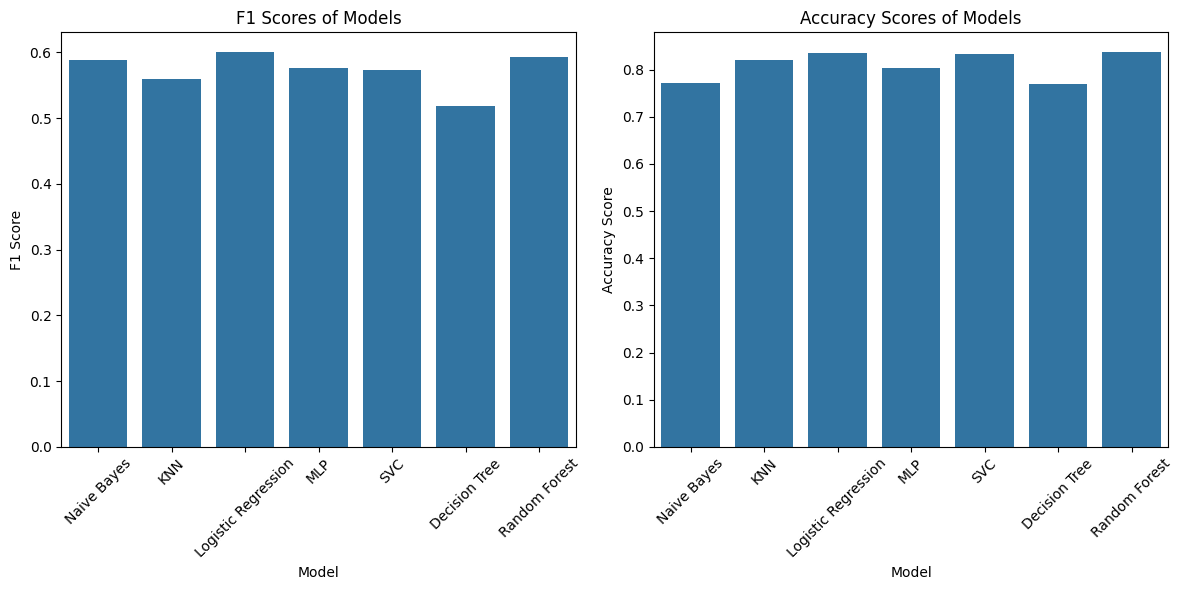

In [272]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

f1_scores_list = list(f1_scores.values())
accuracy_scores_list= list(accuracy_scores.values())
model_names = list(f1_scores.keys())

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=model_names, y=f1_scores_list)
plt.title('F1 Scores of Models')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x=model_names, y=accuracy_scores_list)
plt.title('Accuracy Scores of Models')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Στο σημείο αυτό παρατηρώ ότι το μοντέλο Logistic Regression μου δίνει τα καλύτερα αποτελέσματα/προβλέψεις.

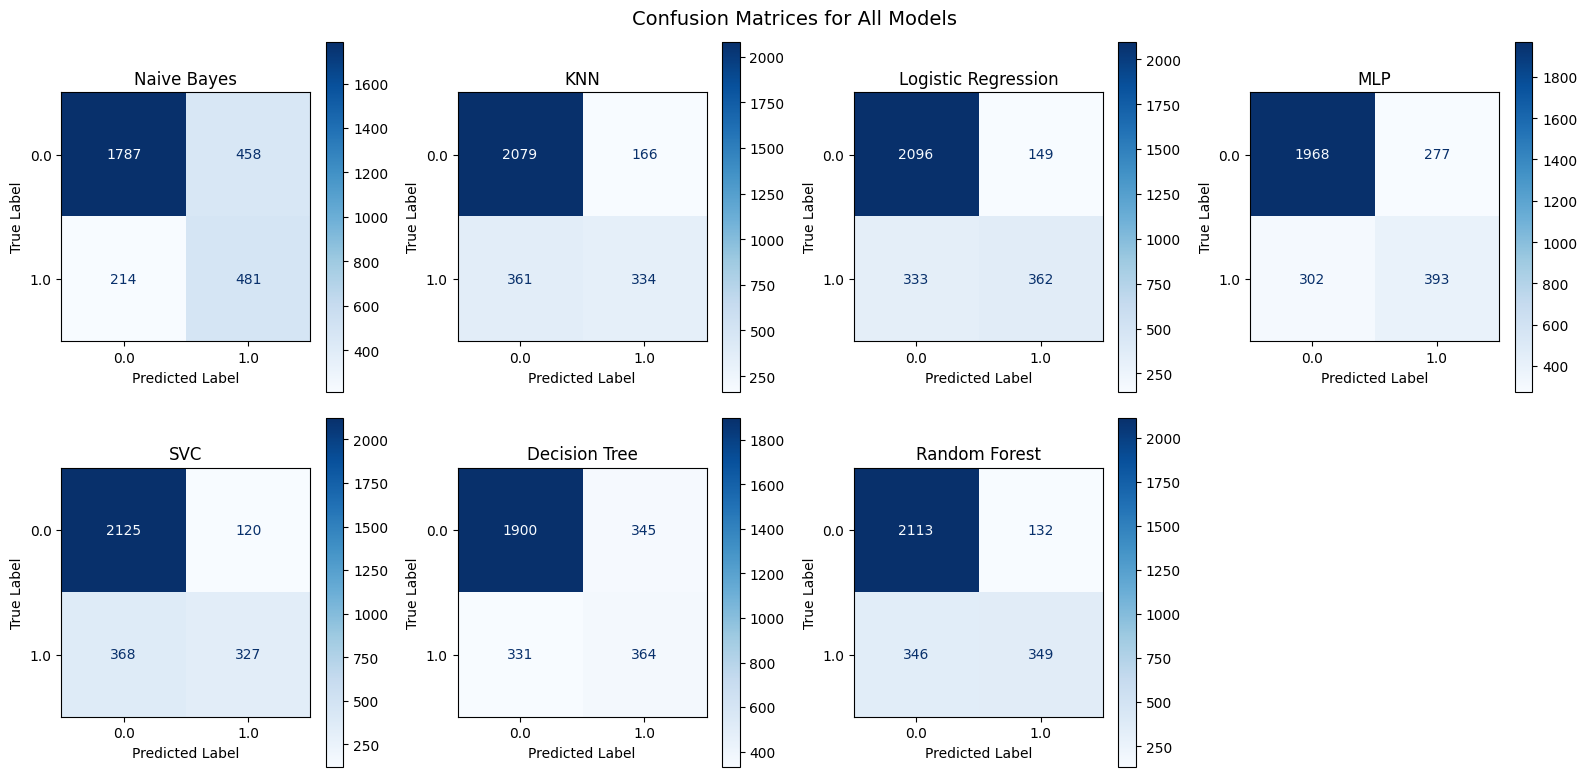

In [273]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Ονόματα ταξινομητών με τη σειρά που τους έχεις εκπαιδεύσει
model_names = [
    "Naive Bayes",
    "KNN",
    "Logistic Regression",
    "MLP",
    "SVC",
    "Decision Tree",
    "Random Forest"
]

#δημιουργία grid για 7 confusion matrixes
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

#δημιουργία plot για κάθε μοντέλο
for i, name in enumerate(model_names):
    model = fit_models_train[name]  #εκπαιδευμένο μοντέλο

    #δημιουργία confusion matrix για το μοντέλο
    matrix = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_processed,
        y_test,
        ax=axes[i],
        cmap=plt.cm.Blues,
        values_format='d'
    )

    #προσαρμογή εμφάνισης
    color = 'black'
    axes[i].set_title(name, color=color)
    axes[i].set_xlabel('Predicted Label', color=color)
    axes[i].set_ylabel('True Label', color=color)
    axes[i].tick_params(axis='x', colors=color)
    axes[i].tick_params(axis='y', colors=color)

    #άδειο subplot (το 8ο)
for j in range(len(model_names), len(axes)):
    fig.delaxes(axes[j])

#τίτλος
fig.suptitle('Confusion Matrices for All Models', color='black', fontsize=14)
fig.tight_layout()
plt.show()

### 5. Βελτιστοποίηση μοντέλων με εύρεση καλύτερων υπερπαραμέτρων των ταξινομητών

**5.α. Για τους 7 ταξινομητές βελτιστοποιήστε την επίδοσή τους χρησιμοποιώντας αναζήτηση πλέγματος με διασταυρούμενη επικύρωση (k-fold 5)  με σκοπό την εύρεση των βέλτιστων υπερπαραμέτρων.**

In [274]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer # Import FunctionTransformer
from scipy.sparse import issparse # Import issparse
import numpy as np
import pandas as pd

Ορίζω τον χώρο αναζήτησης (search space) για το GridSearchCV. Δημιουργώ δηλαδή ένα dictionary με όλα τα μοντέλα και ένα πλέγμα με υπερ-παραμέτρους για το καθένα.

In [275]:
search_space = {
    'Logistic Regression': {
        'to_dense': ['passthrough'],
        'classifier': [LogisticRegression(max_iter=2000, class_weight='balanced')],
        'classifier__solver': ['liblinear', 'saga'],     # saga για μεγάλα/αραιά spaces
        'classifier__C': np.logspace(-2, 1, 6) ,          # 0.01 ... 10
    },
    'SVC': {
        'classifier': [SVC(kernel='rbf', class_weight='balanced')],
        'classifier__C': [0.5, 1, 3, 10],
        'classifier__gamma': ['scale', 0.1, 0.01]
    },

    'KNN': {
       'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [5, 7, 9, 11],
        'classifier__weights': ['uniform', 'distance'],
        'classifier__metric': ['euclidean', 'manhattan']
   },
   'Decision Tree': {
        'classifier': [DecisionTreeClassifier(random_state=42, class_weight='balanced')],
        'classifier__max_depth': [None, 8, 12, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'classifier': [RandomForestClassifier(random_state=42, n_estimators=200, class_weight='balanced')],
      'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5]
    },
        'MLP': {
        'classifier':[MLPClassifier(max_iter=500, random_state=42)],
        'classifier__hidden_layer_sizes':[(50,), (100,), (50,50)],
        'classifier__activation':['relu','tanh'],
        'classifier__alpha':[0.0001,0.001],
       'classifier__learning_rate_init':[0.001,0.01]
   },
   'Naive Bayes': {
      'classifier':[GaussianNB()],
        'classifier__var_smoothing':[1e-9,1e-8,1e-7]
   }
}

#Εδώ ορίζεται το pipeline που εκτελεί για κάθε μοντέλο το processing των δεδομένων

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('to_dense', 'passthrough'),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

f1_positive = make_scorer(f1_score, pos_label=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Ρυθμίζω το GridSearchCV ώστε να χρησιμοποιηθεί το pipeline, να δοκιμαστούν όλες οι παράμετροι και να γίνει 5-fold StratifiedKFold
best_estimators = {}
for name, grid_params in search_space.items():
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid_params,
        cv=cv,
        scoring=f1_positive,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    #εκπαιδεύει πολλά μοντέλα και κάθε φορά αποθηκεύει το καλύτερο στο dictionary best_estimators
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    print(f"{name:20s} | Best F1 (CV): {gs.best_score_:.3f} | Best params: {gs.best_params_}")

Logistic Regression  | Best F1 (CV): 0.633 | Best params: {'classifier': LogisticRegression(class_weight='balanced', max_iter=2000), 'classifier__C': np.float64(0.039810717055349734), 'classifier__solver': 'saga', 'to_dense': 'passthrough'}
SVC                  | Best F1 (CV): 0.643 | Best params: {'classifier': SVC(class_weight='balanced'), 'classifier__C': 1, 'classifier__gamma': 0.1}
KNN                  | Best F1 (CV): 0.570 | Best params: {'classifier': KNeighborsClassifier(), 'classifier__metric': 'euclidean', 'classifier__n_neighbors': 7, 'classifier__weights': 'distance'}
Decision Tree        | Best F1 (CV): 0.580 | Best params: {'classifier': DecisionTreeClassifier(class_weight='balanced', random_state=42), 'classifier__criterion': 'gini', 'classifier__max_depth': 8, 'classifier__min_samples_split': 10}
Random Forest        | Best F1 (CV): 0.635 | Best params: {'classifier': RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=4

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP                  | Best F1 (CV): 0.585 | Best params: {'classifier': MLPClassifier(max_iter=500, random_state=42), 'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate_init': 0.001}
Naive Bayes          | Best F1 (CV): 0.586 | Best params: {'classifier': GaussianNB(), 'classifier__var_smoothing': 1e-09}


**5.β. Εφαρμόστε στα εκπαιδευμένα μοντέλα από το validation set μόνο τα δείγματα χωρίς την ετικέτα τους (predict).**


In [276]:
#Kάνω προβλέψεις στα δεδομένα του test_set χρησιμοποιώντας τα καλύτερα μοντέλα που βρέθηκαν προηγουμένως
test_newpredictions = {}
for clf_name, best_model in best_estimators.items():
    print(f"Evaluating {clf_name} on validation set...")
    y_pred = best_model.predict(X_test)
    test_newpredictions[clf_name] = y_pred


Evaluating Logistic Regression on validation set...
Evaluating SVC on validation set...
Evaluating KNN on validation set...
Evaluating Decision Tree on validation set...
Evaluating Random Forest on validation set...
Evaluating MLP on validation set...
Evaluating Naive Bayes on validation set...


**5.γ. Συγκρίνετε την έξοδο του κάθε μοντέλου σε σχέση με τις αντίστοιχες ετικέτες του validation set και αξιολογήστε την επιδοσή τους χρησιμοποιώντας το F1 score.**


In [277]:
#φτιάχνω λεξικό για να αποθηκεύσω το f1_score για κάθε ταξινομητή
f1_newscores = {}

#υπολογίζω f1_score
for clf_name, best_model in best_estimators.items():
    f1 = f1_score(y_test, test_newpredictions[clf_name])
    f1_newscores[clf_name] = f1

print("F1 Scores for all classifiers on validation set:")
for clf_name, f1 in f1_newscores.items():
    print(f"{clf_name}: {f1:.4f}")

F1 Scores for all classifiers on validation set:
Logistic Regression: 0.6098
SVC: 0.6370
KNN: 0.5516
Decision Tree: 0.5768
Random Forest: 0.6261
MLP: 0.5747
Naive Bayes: 0.5887


**5.δ.  Αξιολογήστε συνολικά την επίδοση των μοντέλων χρησιμοποιώντας κάποιο γράφημα (π.χ. ιστόγραμμα, bar plot) και σχολιάστε ποιο μοντέλο είχε την καλύτερη επίδοση.**


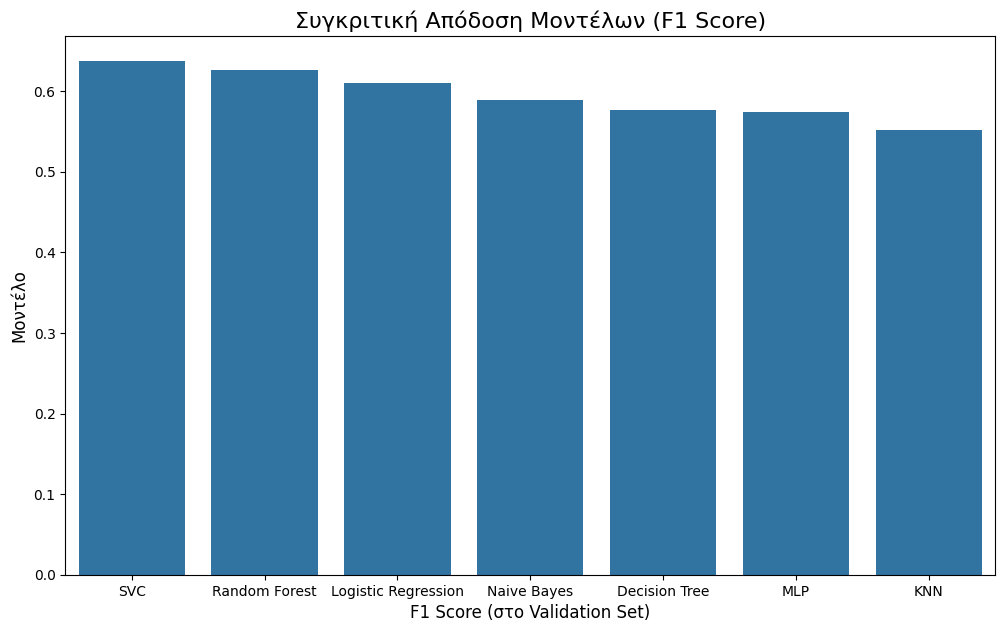

In [278]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

f1_series = pd.Series(f1_newscores)

#Ταξινόμηση των τιμών (από τη μεγαλύτερη στη μικρότερη)
f1_series = f1_series.sort_values(ascending=False)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=f1_series.index,
    y=f1_series.values)

plt.title('Συγκριτική Απόδοση Μοντέλων (F1 Score)', fontsize=16)
plt.xlabel('F1 Score (στο Validation Set)', fontsize=12)
plt.ylabel('Μοντέλο', fontsize=12)

plt.show()

### 6. Έλεγχος επίδοσης βελτιστοποιημένων μοντέλων

**6.α. Εφαρμόστε τους επτά βελτιστοποιημένους ταξινομητές στα δείγματα του test set(χωρίς τις ετικέτες του) για την παραγωγή προβλέψεων (predict).**

Στο σημείο αυτό επειδή έχω ένα νέο dataset θα πρέπει να επαναλάβω μερικά από τα βήματα που έκανα προηγουμένως. Για τον λόγο αυτό είχα δημιουργήσει συναρτήσεις που διευκολύνουν τη διαδικασία αυτή.

In [279]:
#φορτώνω το νέο dataset
df1 = pd.read_csv("test.csv")
df1['Location'].unique()

array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond',
       'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat',
       'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura',
       'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns',
       'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa',
       'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport',
       'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston',
       'AliceSprings', 'Darwin', 'Katherine', 'Uluru'], dtype=object)

In [280]:
#δημιουργώ το dictionary με τις συντεταγμένες που θα χρειαστώ στη συνέχεια
location_coordinates = {
    "Albury": (-36.0805, 146.9167),
    "BadgerysCreek": (-33.8824, 150.7510),
    "Cobar": (-31.4983, 145.8344),
    "CoffsHarbour": (-30.3022, 153.1157),
    "Moree": (-29.4650, 149.8440),
    "Newcastle": (-32.9283, 151.7817),
    "NorahHead": (-33.2817, 151.5694),
    "NorfolkIsland": (-29.0408, 167.9547),
    "Penrith": (-33.7510, 150.6940),
    "Richmond": (-33.6004, 150.7506),
    "Sydney": (-33.8688, 151.2093),
    "SydneyAirport": (-33.9461, 151.1772),
    "WaggaWagga": (-35.1083, 147.3689),
    "Williamtown": (-32.8150, 151.8422),
    "Wollongong": (-34.4278, 150.8931),
    "Canberra": (-35.2809, 149.1300),
    "Tuggeranong": (-35.4209, 149.0921),
    "MountGinini": (-35.5303, 148.7844),
    "Ballarat": (-37.5622, 143.8503),
    "Bendigo": (-36.7570, 144.2794),
    "Sale": (-38.1130, 147.0700),
    "MelbourneAirport": (-37.6733, 144.8433),
    "Melbourne": (-37.8136, 144.9631),
    "Mildura": (-34.1848, 142.1625),
    "Nhil": (-36.3323, 141.6502),
    "Portland": (-38.3444, 141.6033),
    "Watsonia": (-37.7130, 145.0830),
    "Dartmoor": (-37.9250, 141.2721),
    "Brisbane": (-27.4698, 153.0251),
    "Cairns": (-16.9255, 145.7754),
    "GoldCoast": (-28.0167, 153.4000),
    "Townsville": (-19.2590, 146.8169),
    "Adelaide": (-34.9285, 138.6007),
    "MountGambier": (-37.8295, 140.7797),
    "Nuriootpa": (-34.4690, 138.9950),
    "Woomera": (-31.1997, 136.8300),
    "Albany": (-35.0228, 117.8814),
    "Witchcliffe": (-34.0250, 115.0970),
    "PearceRAAF": (-31.6667, 116.0167),
    "PerthAirport": (-31.9403, 115.9669),
    "Perth": (-31.9505, 115.8605),
    "SalmonGums": (-32.9806, 121.6444),
    "Walpole": (-34.9775, 116.7319),
    "Hobart": (-42.8821, 147.3272),
    "Launceston": (-41.4388, 147.1347),
    "AliceSprings": (-23.7000, 133.8800),
    "Darwin": (-12.4634, 130.8456),
    "Katherine": (-14.4646, 132.2636),
    "Uluru": (-25.3444, 131.0369)
}

In [281]:
#επαναλαμβάνω τα ίδια ακριβώς βήματα
df1=create_features(df1)
df1=create_date(df1)
df1=create_features2(df1)
df1=make_rain_binary(df1)
df1=drop_col(df1)
df1=drop_nan(df1)
df1=impute_cat(df1)
df1=impute_num(df1)
df1=create_loc(df1)
X1, y1, cat_cols, loc_cols, cyclical_cols, num_cols = split_features(df1)

/tmp/ipython-input-3751123730.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  date_time = pd.to_datetime(df_out['Date'])
/tmp/ipython-input-3788031969.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_out[col].fillna(df_out[col].mode()[0], inplace=True)


MinTemp               0
MaxTemp               0
Rainfall              0
Sunshine              0
WindGustSpeed         0
WindSpeed9am          0
Humidity9am           0
Humidity3pm           0
Pressure3pm           0
Cloud9am              0
Cloud3pm              0
TempDiff              0
HumidityDiff          0
WindSpeedMean         0
CloudMean             0
HumidityMean          0
PressureMean          0
day_sin               0
day_cos               0
ThermalInstability    0
RainMomentum          0
RainTomorrow_num      0
RainToday_num         0
dtype: int64


Στο σημείο αυτό έχω επεξεργαστεί το νέο dataset μέχρι ένα σημείο. Αυτή τη φορά δεν θα χρειαστεί να το χωρίσω σε training και validation set, γιατί αποτελεί ολόκληρο ένα test set για τα μοντέλα που προηγουμένως εκπαίδευσα και χρησιμοποίησα για τις προβλέψεις μου. Το μόνο που χρειάζεται να κάνω είναι ένα predict σε ολόκληρο το dataset που έχω επιλέξει (μετά απο μία μικρή επεξεργασία). Bέβαια predict κάνω χρησιμοποιώντας τα καλύτερα μοντέλα από προηγουμένως και η διαδικασία του predict καλύπτει και την διαδικασία του preprocessing, καθώς αυτή ακριβώς είναι η λειτουργία του pipeline που έχω υλοποιήσει προηγουμένως.

In [282]:
test_newpredictions = {}
for clf_name, best_model in best_estimators.items():
    print(f"Evaluating {clf_name} on validation set...")
    y_pred = best_model.predict(X1)#_test)
    test_newpredictions[clf_name] = y_pred

Evaluating Logistic Regression on validation set...
Evaluating SVC on validation set...
Evaluating KNN on validation set...
Evaluating Decision Tree on validation set...
Evaluating Random Forest on validation set...
Evaluating MLP on validation set...
Evaluating Naive Bayes on validation set...


**6.β. Συγκρίνετε την έξοδο του κάθε ταξινομητή σε σχέση με τις αντίστοιχες ετικέτες του test set και αξιολογήστε την επιδοσή τους χρησιμοποιώντας το Precision και το recall.**



In [284]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

#δημιουργώ λεξικά για τα αποτελέσματα
precision_scores = {}
recall_scores = {}
f1_scores = {}

#για κάθε ταξινομητή, συγκρίνουμε τις προβλέψεις του με τις πραγματικές ετικέτες
for name, model in best_estimators.items():
    y_pred = model.predict(X1)
    precision_scores[name] = precision_score(y1, y_pred)
    recall_scores[name] = recall_score(y1, y_pred)
    f1_scores[name] = f1_score(y1, y_pred, zero_division=0)

#συνολικά
results_df = pd.DataFrame({
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1-score": f1_scores
})

display(results_df)

#εμφάνιση του καλύτερου κατά precision και recall
best_precision = max(precision_scores, key=precision_scores.get)
best_recall = max(recall_scores, key=recall_scores.get)

print(f"Καλύτερο Precision: {best_precision} ({precision_scores[best_precision]:.3f})")
print(f"Καλύτερο Recall: {best_recall} ({recall_scores[best_recall]:.3f})")
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

,Precision,Recall,F1-score
Logistic Regression,0.554594,0.781426,0.648754
SVC,0.598075,0.757974,0.668597
KNN,0.717742,0.500938,0.590055
Decision Tree,0.502338,0.705441,0.586812
Random Forest,0.654189,0.688555,0.670932
MLP,0.638655,0.570356,0.602577
Naive Bayes,0.494878,0.725141,0.588280


Καλύτερο Precision: KNN (0.718)
Καλύτερο Recall: Logistic Regression (0.781)


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

**6.γ. Αξιολογήστε συνολικά την επίδοση των βελτιστοποιημένων μοντέλων στο test set, χρησιμοποιώντας κάποιο γράφημα (π.χ. ιστόγραμμα, bar plot) και σχολιάστε ποιο μοντέλο είχε την καλύτερη επίδοση.**

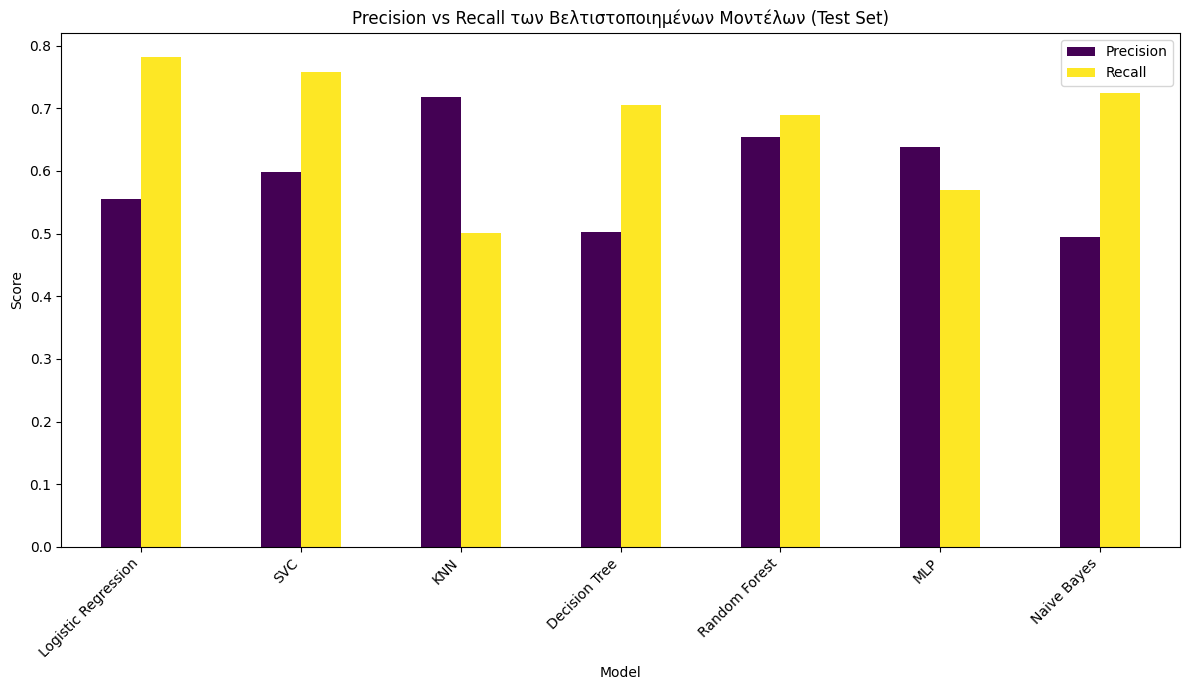

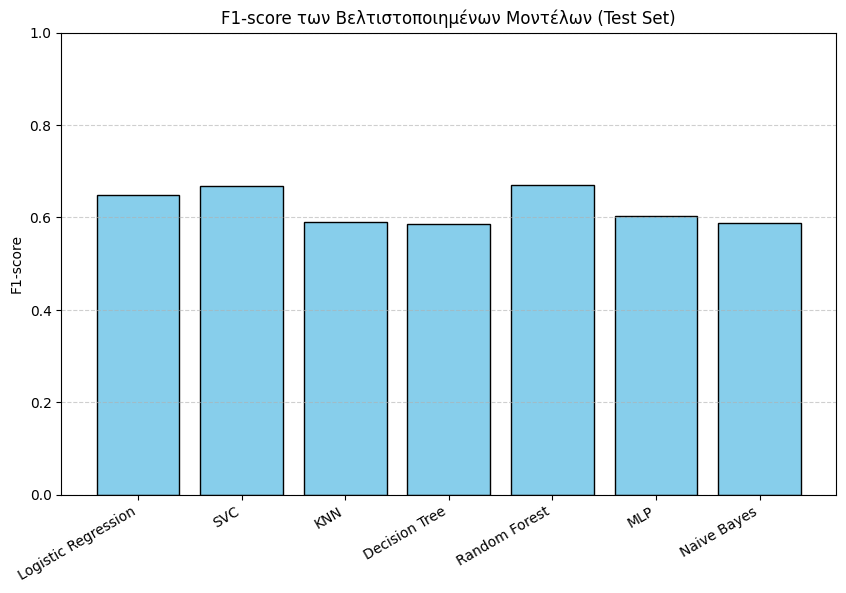

Evaluating Logistic Regression...


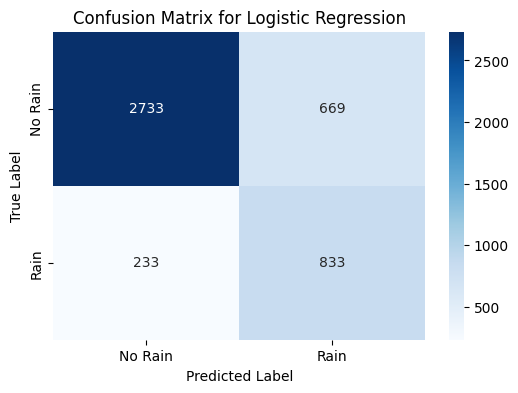

Evaluating SVC...


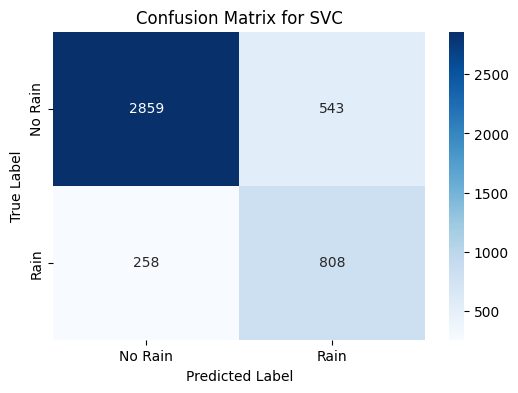

Evaluating KNN...


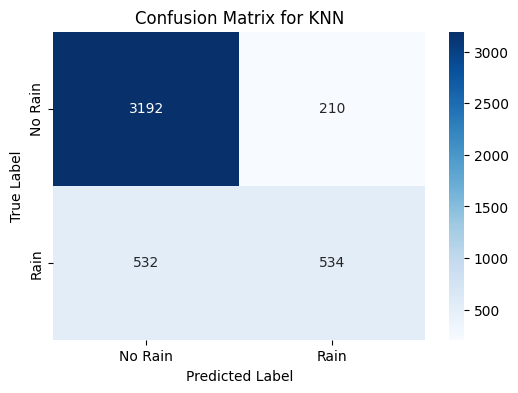

Evaluating Decision Tree...


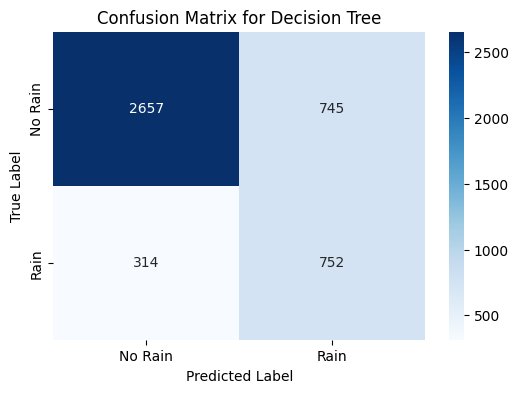

Evaluating Random Forest...


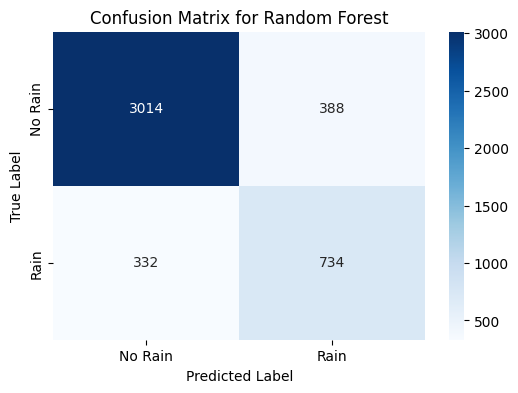

Evaluating MLP...


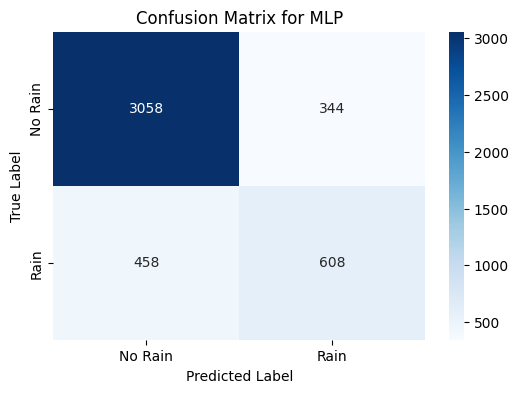

Evaluating Naive Bayes...


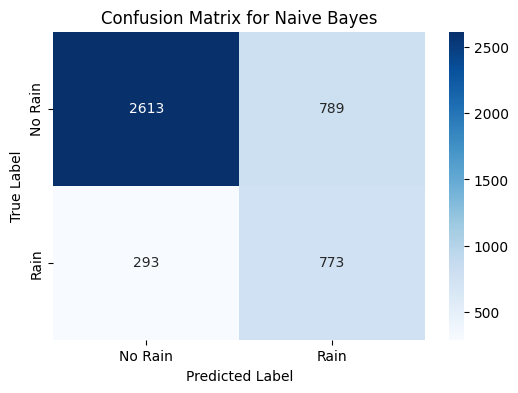

In [285]:
#Bar plot Precision και Recall
results_df[['Precision', 'Recall']].plot(kind='bar', figsize=(12, 7), colormap='viridis')
plt.title("Precision vs Recall των Βελτιστοποιημένων Μοντέλων (Test Set)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#f1 scores
plt.figure(figsize=(10,6))
plt.bar(f1_scores.keys(), f1_scores.values(), color='skyblue', edgecolor='black')
plt.title("F1-score των Βελτιστοποιημένων Μοντέλων (Test Set)")
plt.ylabel("F1-score")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

for clf_name, clf in best_estimators.items():
    print(f"Evaluating {clf_name}...")
    y_pred = clf.predict(X1)
    plot_confusion_matrix(y1, y_pred, clf_name)

**ΕΡΩΤΗΣΕΙΣ**

1.  **Ποιο μοντέλο παρουσιάζει την καλύτερη συνολική ισορροπία μεταξύ precision και recall;**
    > Το μοντέλο Random Forest παρουσιάζει την καλύτερη ισορροπία μεταξύ Precision και Recall, με F1-score σχεδόν 0.68. Αυτό φαίνεται και από το bar plot των Precision και Recall.
    > Η επίδοση αυτή οφείλεται πιθανώς στην ικανότητα των Random Forests να χειρίζονται μη-γραμμικές σχέσεις στα δεδομένα. Επίσης, συνδυάζουν τις προβλέψεις πολλαπλών δέντρων αποφάσεων, μειώνοντας το overfitting σε σχέση με ένα μεμονωμένο Decision Tree. Τέλος, είναι πολύ καλό στο να χειρίζεται τις συσχετισμένες στήλες.

2.  **Ποιο μοντέλο εμφανίζει τη μεγαλύτερη διακύμανση στις επιδόσεις του, μεταξύ διαφορετικών folds ή runs;**
    > Από τα αποτελέσματα της GridSearchCV, το Decision Tree εμφανίζει το χαμηλότερο F1-score, ενώ μοντέλα όπως το Random Forest και το Logistic Regression έχουν υψηλότερα (0.635 και 0.633 αντίστοιχα). Τα Decision Trees είναι ευαίσθητα σε μικρές αλλαγές στα δεδομένα εκπαίδευσης άρα εύκολα μπορεί να οδογηθεί σε τελείως διαφορετικό αποτέλεσμα. Μια αρχική διαφορετική απόφαση αλλά σε μεγάλο βαθμό την δομή του αρχικού δέντρου, άρα και τη συνέχειά του.   

3.  **Ποιο μοντέλο φαίνεται να υπερεκπαιδεύεται (overfitting) ή να υποεκπαιδεύεται (underfitting) με βάση τη σύγκριση των train και test scores;**
    > Στα συγκεκριμένα αποτελέσματα δεν παρατηρούμε μεγάλες αποστάσεις στα αποτελέσματα του f1 του training-validation set. Με μικρές διαφορές όμως μπορούμε να κάνουμε έναν σχολιασμό.
    > *   **Decision Tree**: Συχνά τα Decision Trees μπορούν να υπερεκπαιδευτούν, γιατί εύκολα "αποστηθίζουν" τα δεδομένα εκπαίδευσης. Αν το F1 score στο train set ήταν πολύ υψηλό και στο test set (0.577) σχετικά χαμηλότερο, αυτό θα έδειχνε overfitting.
    > *   **Naive Bayes**: Συχνά υποεκπαιδεύεται σε σύγκριση με πιο πολύπλοκα μοντέλα, καθώς κάνει ισχυρές υποθέσεις για την ανεξαρτησία των χαρακτηριστικών.
    > *   **Logistic Regression**: Είναι ένα γραμμικό μοντέλο και για αυτό είναι ίσως πολύ απλο για να κατανοήσει την πολυπλοκότητα του μη-γραμμικού προβλήματος πρόβλεψης του καιρού.

4.  **Ποια κατηγορία παρουσιάζει τα περισσότερα σφάλματα ταξινόμησης και γιατί;**
    > Αναλύοντας τα confusion matrixes (ιδιαίτερα του Random Forest που είχε την καλύτερη επίδοση στο test set) βλέπουμε ότι η κατηγορία που παρουσιάζει τα περισσότερα σφάλματα ταξινόμησης είναι η "No Rain"
    >Ο κύριος λόγος είναι το ανισόρροπο dataset (imbalanced dataset).Η "Rain" είναι η σπάνια κλάση, κάτι το οποίο αντιλαμβανόμαστε από το σύνολο κάθε κλάσης σύμφωνα με τα διαγράμματα.
    >Για τον λόγο αυτό ένα μοντέλο γίνεται υπερευαίσθητο και προσπαθεί να μάθει να βρίσκει τη σπάνια κλάση και για αυτό καταλήγει σε λανθασμένες ταξινομήσεις.
    > ίσως και η ρύθμιση class_weight='balanced' να προκάλεσε το αποτέλεσμα αυτό.

    
